### Text Rating Prediction

Text Rating Prediction — это задача машинного обучения, которая заключается в предсказании рейтинга (например, от 1 до 5 звёзд) на основе текста отзыва. В последние годы с ростом онлайн-торговли и платформ для отзывов, таких как Amazon, eBay, и Google Reviews, значимость такой задачи значительно возросла, поскольку качественная система предсказания рейтингов помогает автоматизировать оценку продуктов и услуг, улучшая взаимодействие с пользователями и ускоряя обработку больших объемов данных.

#### Цель задачи

Целью данной задачи является создание модели, которая сможет предсказывать рейтинг товара или услуги, исходя только из текстового отзыва пользователя. Эта модель будет использовать текстовые данные (например, описания, мнения и комментарии пользователей) для оценки и предсказания, насколько положительным или отрицательным будет рейтинг.

Задача имеет важное практическое применение в таких областях, как:

* Автоматическое модерирование отзывов: определение позитивных и негативных отзывов для автоматической фильтрации.

* Оценка качества товаров и услуг на основании пользовательских отзывов.

*  Повышение точности рекомендательных систем, которые могут прогнозировать рейтинг продукта для каждого пользователя, основываясь на исторических данных и текстах отзывов.

#### Методы решения

Для решения этой задачи можно использовать различные подходы:

* Обработка текста (NLP): Преобразование текста в числовые признаки с помощью таких методов, как CountVectorizer или TF-IDF, или использование более сложных методов, таких как Word2Vec, GloVe и BERT.

* Модели машинного обучения: После извлечения признаков из текста можно применить различные модели классификации, такие как Logistic Regression, Random Forest, XGBoost или Neural Networks.

* Использование предварительно обученных эмбеддингов: Модели типа BERT или DistilBERT могут быть использованы для создания более мощных представлений текста, что существенно повысит точность предсказания.

#### Значимость и вызовы

Основной вызов в задаче Text Rating Prediction заключается в том, чтобы правильно интерпретировать смысл текста и учитывать контекст, который может сильно повлиять на рейтинг. Например, одни и те же слова могут иметь различные коннотации в зависимости от контекста, и это важно учитывать при обучении модели. Также модель должна справляться с проблемой многозначности и слабой корреляции между текстом и рейтингом в некоторых случаях.

Таким образом, успешное решение задачи предсказания рейтинга по тексту может значительно повысить эффективность обработки отзывов и улучшить пользовательский опыт в онлайн-торговле и других сферах, где важны мнения и оценки пользователей.

In [1]:
import pandas as pd
import numpy as np

In [2]:
from utils.baseline import *

In [3]:
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.multiclass import OneVsRestClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.pipeline import Pipeline
#from sklearn.feature_selection import 
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, OrdinalEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from statsmodels.stats.outliers_influence import variance_inflation_factor

import spacy
import os
from gensim.models import Word2Vec
from transformers import BertTokenizer, TFBertModel, TFAutoModelForSequenceClassification, BertForSequenceClassification

In [4]:
from matplotlib import pyplot as plt
import seaborn as sns

In [5]:
import torch

In [6]:
import tensorflow
from keras.models import Sequential
from keras.layers import Activation, Dense, LSTM, GRU, Flatten, Dropout, Embedding, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer                               # type: ignore
from tensorflow.keras.preprocessing.sequence import pad_sequences                       # type: ignore
from tensorflow.keras.optimizers import Adam                                            # type: ignore
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau                 # type: ignore

### 1. Загрузка данных

In [7]:
data = pd.read_csv('./data/Mobile Reviews Sentiment Pred.csv', index_col=0, parse_dates=['review_date'])

In [8]:
data.head(5)

,age,brand,model,price_usd,rating,review_text,sentiment,country,review_date,verified_purchase,battery_life_rating,camera_rating,performance_rating,design_rating,display_rating,word_count,helpful_votes,source
0,45,Realme,Realme 12 Pro,337.31,2,Not worth the money spent. Wouldn’t recommend.,0,India,2023-11-06,1,1,1,3,2,1,7,1,Amazon
1,18,Realme,Realme 12 Pro,307.78,4,Absolutely love this phone! The camera is next...,2,Brazil,2023-03-30,1,3,2,4,3,2,12,5,Flipkart
2,27,Google,Pixel 6,864.53,4,Loving the clean UI and fast updates. Loving i...,2,India,2022-12-07,1,3,5,3,2,4,11,8,AliExpress
3,19,Xiaomi,Redmi Note 13,660.94,3,Build quality feels solid and durable. No regr...,2,UAE,2025-03-11,0,1,3,2,1,2,11,3,Amazon
4,38,Motorola,Edge 50,792.13,3,Not bad for daily use but could be optimized. ...,1,Brazil,2023-09-29,1,3,3,2,2,1,12,0,BestBuy


In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50000 entries, 0 to 49999
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   age                  50000 non-null  int64         
 1   brand                50000 non-null  object        
 2   model                50000 non-null  object        
 3   price_usd            50000 non-null  float64       
 4   rating               50000 non-null  int64         
 5   review_text          50000 non-null  object        
 6   sentiment            50000 non-null  int64         
 7   country              50000 non-null  object        
 8   review_date          50000 non-null  datetime64[ns]
 9   verified_purchase    50000 non-null  int64         
 10  battery_life_rating  50000 non-null  int64         
 11  camera_rating        50000 non-null  int64         
 12  performance_rating   50000 non-null  int64         
 13  design_rating        50000 non-null 

### 2. Преобразование данных

В данном фрагменте кода производится подготовка данных для задачи Text Rating Prediction, где целью является предсказание рейтинга продукта на основе текстового отзыва. Процесс подготовки данных включает несколько этапов, таких как очистка текста, преобразование категориальных переменных, создание новых признаков, и удаление ненужных колонок.

На первом этапе создаётся объект класса PreprocessingText, который содержит метод clean_text, предназначенный для очистки текстовых данных. Этот метод применяется к каждому отзыву в колонке review_text. После обработки результат сохраняется в новой колонке clean_text. Очистка текста может включать в себя такие операции, как:

* удаление стоп-слов,

* приведение текста к нижнему регистру,

* удаление пунктуации и чисел,

* лемматизация.

In [10]:
path = './data/clean_text.txt'

if os.path.exists(path):
    with open(path, mode='r', encoding='utf-8') as f:
        data['clean_text'] = [line.strip() for line in f.readlines()]

else:
    prep = PreprocessingText()
    data['clean_text'] = prep.process_texts_in_parallel(data['review_text'])
    
    with open(path, mode='w', encoding='utf-8') as f:
        f.writelines(data['clean_text'].apply(lambda x: x + '\n'))

Здесь изначально выделяются категориальные и числовые признаки:

* categorical_columns — это список всех столбцов, содержащих категориальные данные.

* numeric_columns — это список столбцов с числовыми значениями, такими как возраст, рейтинг и другие количественные признаки.

В процессе фильтрации из списка категориальных признаков исключаются `review_text` и `clean_text`, так как эти столбцы не требуют преобразования через one-hot encoding.

In [11]:
categorical_columns = data.select_dtypes(include=['object']).columns.to_list()
numeric_columns = data.select_dtypes(include=['int', 'float']).columns.to_list()

In [12]:
categorical_columns = [col for col in categorical_columns if col not in ['review_text', 'clean_text']]

Для преобразования категориальных признаков используется метод pd.get_dummies(), который выполняет one-hot encoding для всех категориальных признаков в данных. Это преобразует категориальные значения в бинарные столбцы. Параметр drop_first=True используется для исключения первой категории в каждом признаке, что помогает избежать мультиколлинеарности.

In [13]:
data = pd.get_dummies(data, columns=categorical_columns, drop_first=True)

Целевая переменная `rating` преобразуется для бинарной классификации. Рейтинги 1 и 2 превращаются в 0 (плохие оценки), а 4 и 5 — в 1 (хорошие оценки). Это позволяет классифицировать отзывы как позитивные или негативные, что упрощает задачу и фокусируется на наиболее значимых признаках.

In [14]:
data['rating'] = data['rating'].map({1 : 0, 2 : 0, 4 : 1, 5 : 1})

Здесь удаляются строки с пропущенными значениями в колонке `rating`, так как модель не сможет обучаться с отсутствующими метками для целевой переменной.

In [15]:
data = data.dropna(subset=['rating'])

После этого столбец `rating` преобразуется в тип int, чтобы убедиться, что значения могут быть правильно интерпретированы как целочисленные для классификации.

In [16]:
data['rating'] = data['rating'].astype('int')

Здесь создаётся новый признак `rating_phone`, который является средним значением по оценкам различных характеристик телефона: `battery_life_rating`, `camera_rating`, `performance_rating`, `design_rating`, и `display_rating`. Этот признак может быть полезен для улучшения предсказания рейтинга, так как включает в себя объективные характеристики устройства.

In [17]:
data['rating_phone'] = data[['battery_life_rating', 'camera_rating', 'performance_rating', 'design_rating', 'display_rating']].mean(axis=1)

После создания нового признака `rating_phone`, исходные столбцы, содержащие индивидуальные оценки характеристик, удаляются, чтобы избежать избыточности и упрощения модели.

In [18]:
data = data.drop(columns=['battery_life_rating', 'camera_rating', 'performance_rating', 'design_rating', 'display_rating'], axis=1)

Теперь выделяются признаки (X) и целевая переменная (y). В данном случае X_review — это текстовый столбец `review_text`, который будет использоваться для предсказания рейтинга, а y — это столбец `rating`, который содержит метки классов (позитивный или негативный рейтинг).

In [19]:
X = data['clean_text']
y = data['rating']

In [20]:
print(f'Среднее количество слов в отзыве: {round(data['word_count'].mean())}')

Среднее количество слов в отзыве: 11


In [21]:
data.head(5)

,age,price_usd,rating,review_text,sentiment,review_date,verified_purchase,word_count,helpful_votes,clean_text,...,country_Germany,country_India,country_UAE,country_UK,country_USA,source_Amazon,source_BestBuy,source_Flipkart,source_eBay,rating_phone
0,45,337.31,0,Not worth the money spent. Wouldn’t recommend.,0,2023-11-06,1,7,1,worth money spend not recommend,...,False,True,False,False,False,True,False,False,False,1.6
1,18,307.78,1,Absolutely love this phone! The camera is next...,2,2023-03-30,1,12,5,absolutely love phone camera level absolutely ...,...,False,False,False,False,False,False,False,True,False,2.8
2,27,864.53,1,Loving the clean UI and fast updates. Loving i...,2,2022-12-07,1,11,8,love clean ui fast update love far,...,False,True,False,False,False,False,False,False,False,3.4
5,38,948.79,1,Battery easily lasts a day with heavy use. No ...,2,2023-06-27,0,13,6,battery easily last day heavy use regret buy,...,False,False,False,False,False,False,False,False,False,4.6
7,39,1443.76,0,"Phone hangs often, regret buying it. Wouldn’t ...",0,2024-04-08,1,8,3,phone hang regret buy not recommend,...,False,False,False,False,False,True,False,False,False,1.8


### 3. Baseline

In [22]:
X_train, X_val_test, y_train, y_val_test = train_test_split(X, y, test_size=0.4, shuffle=True, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_val_test, y_val_test, test_size=0.5, shuffle=True, random_state=42)

In [23]:
values = [X_train, y_train, X_val, y_val]

In [24]:
baseline, baseline_metrics  = PipelineManager(values, CountVectorizer(), LogisticRegression(class_weight='balanced')).create_pipeline()

              precision    recall  f1-score   support

           0       0.91      0.94      0.92      3222
           1       0.95      0.93      0.94      4288

    accuracy                           0.93      7510
   macro avg       0.93      0.93      0.93      7510
weighted avg       0.93      0.93      0.93      7510



### 4. Improvements

#### 4.1. Classic ML

In [25]:
tf_log, tf_log_metrics = PipelineManager(values, TfidfVectorizer(), LogisticRegression(class_weight='balanced')).create_pipeline()

              precision    recall  f1-score   support

           0       0.91      0.94      0.92      3222
           1       0.95      0.93      0.94      4288

    accuracy                           0.93      7510
   macro avg       0.93      0.93      0.93      7510
weighted avg       0.93      0.93      0.93      7510



In [26]:
tf_forest, tf_forest_metrics = PipelineManager(values, TfidfVectorizer(), RandomForestClassifier(class_weight='balanced')).create_pipeline()

              precision    recall  f1-score   support

           0       0.91      0.94      0.92      3222
           1       0.95      0.93      0.94      4288

    accuracy                           0.93      7510
   macro avg       0.93      0.93      0.93      7510
weighted avg       0.93      0.93      0.93      7510



#### 4.2. Neural Networks

In [27]:
tokenazer = Tokenizer()
tokenazer.fit_on_texts(X)
X_token = tokenazer.texts_to_sequences(X)

In [28]:
seq_lens = [len(seq) for seq in X_token]
vocab_size = len(tokenazer.word_index) + 1

In [29]:
max_len = int(np.percentile(seq_lens, 95))

In [30]:
X_token = pad_sequences(X_token, padding='post', maxlen=max_len)

In [31]:
X_train_token, X_val_token, y_train_token, y_val_token = train_test_split(X_token, y, test_size=0.2, random_state=42)

In [32]:
model = Sequential()
model.add(Embedding(input_dim=vocab_size, output_dim=100, input_length=seq_lens))
model.add(Bidirectional(GRU(128, return_sequences=False)))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))

early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-6)

model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
model.fit(X_train_token, y_train_token, epochs=3, batch_size=16, validation_data=(X_val_token, y_val_token), callbacks=[early_stopping, reduce_lr])

pred_lstm = model.predict(X_val_token)
pred_lstm = (pred_lstm > 0.5).astype('int')

print(classification_report(y_val_token, pred_lstm))


Epoch 1/3


c:\Users\46120\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


1878/1878 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9391 - loss: 0.2147 - val_accuracy: 0.9358 - val_loss: 0.2174 - learning_rate: 0.0010
Epoch 2/3
1878/1878 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9417 - loss: 0.2042 - val_accuracy: 0.9358 - val_loss: 0.2127 - learning_rate: 0.0010
Epoch 3/3
1878/1878 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9417 - loss: 0.2034 - val_accuracy: 0.9358 - val_loss: 0.2127 - learning_rate: 0.0010
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
              precision    recall  f1-score   support

           0       0.91      0.94      0.92      3144
           1       0.95      0.94      0.94      4367

    accuracy                           0.94      7511
   macro avg       0.93      0.94      0.93      7511
weighted avg       0.94      0.94      0.94      7511



In [33]:
history = model.history.history

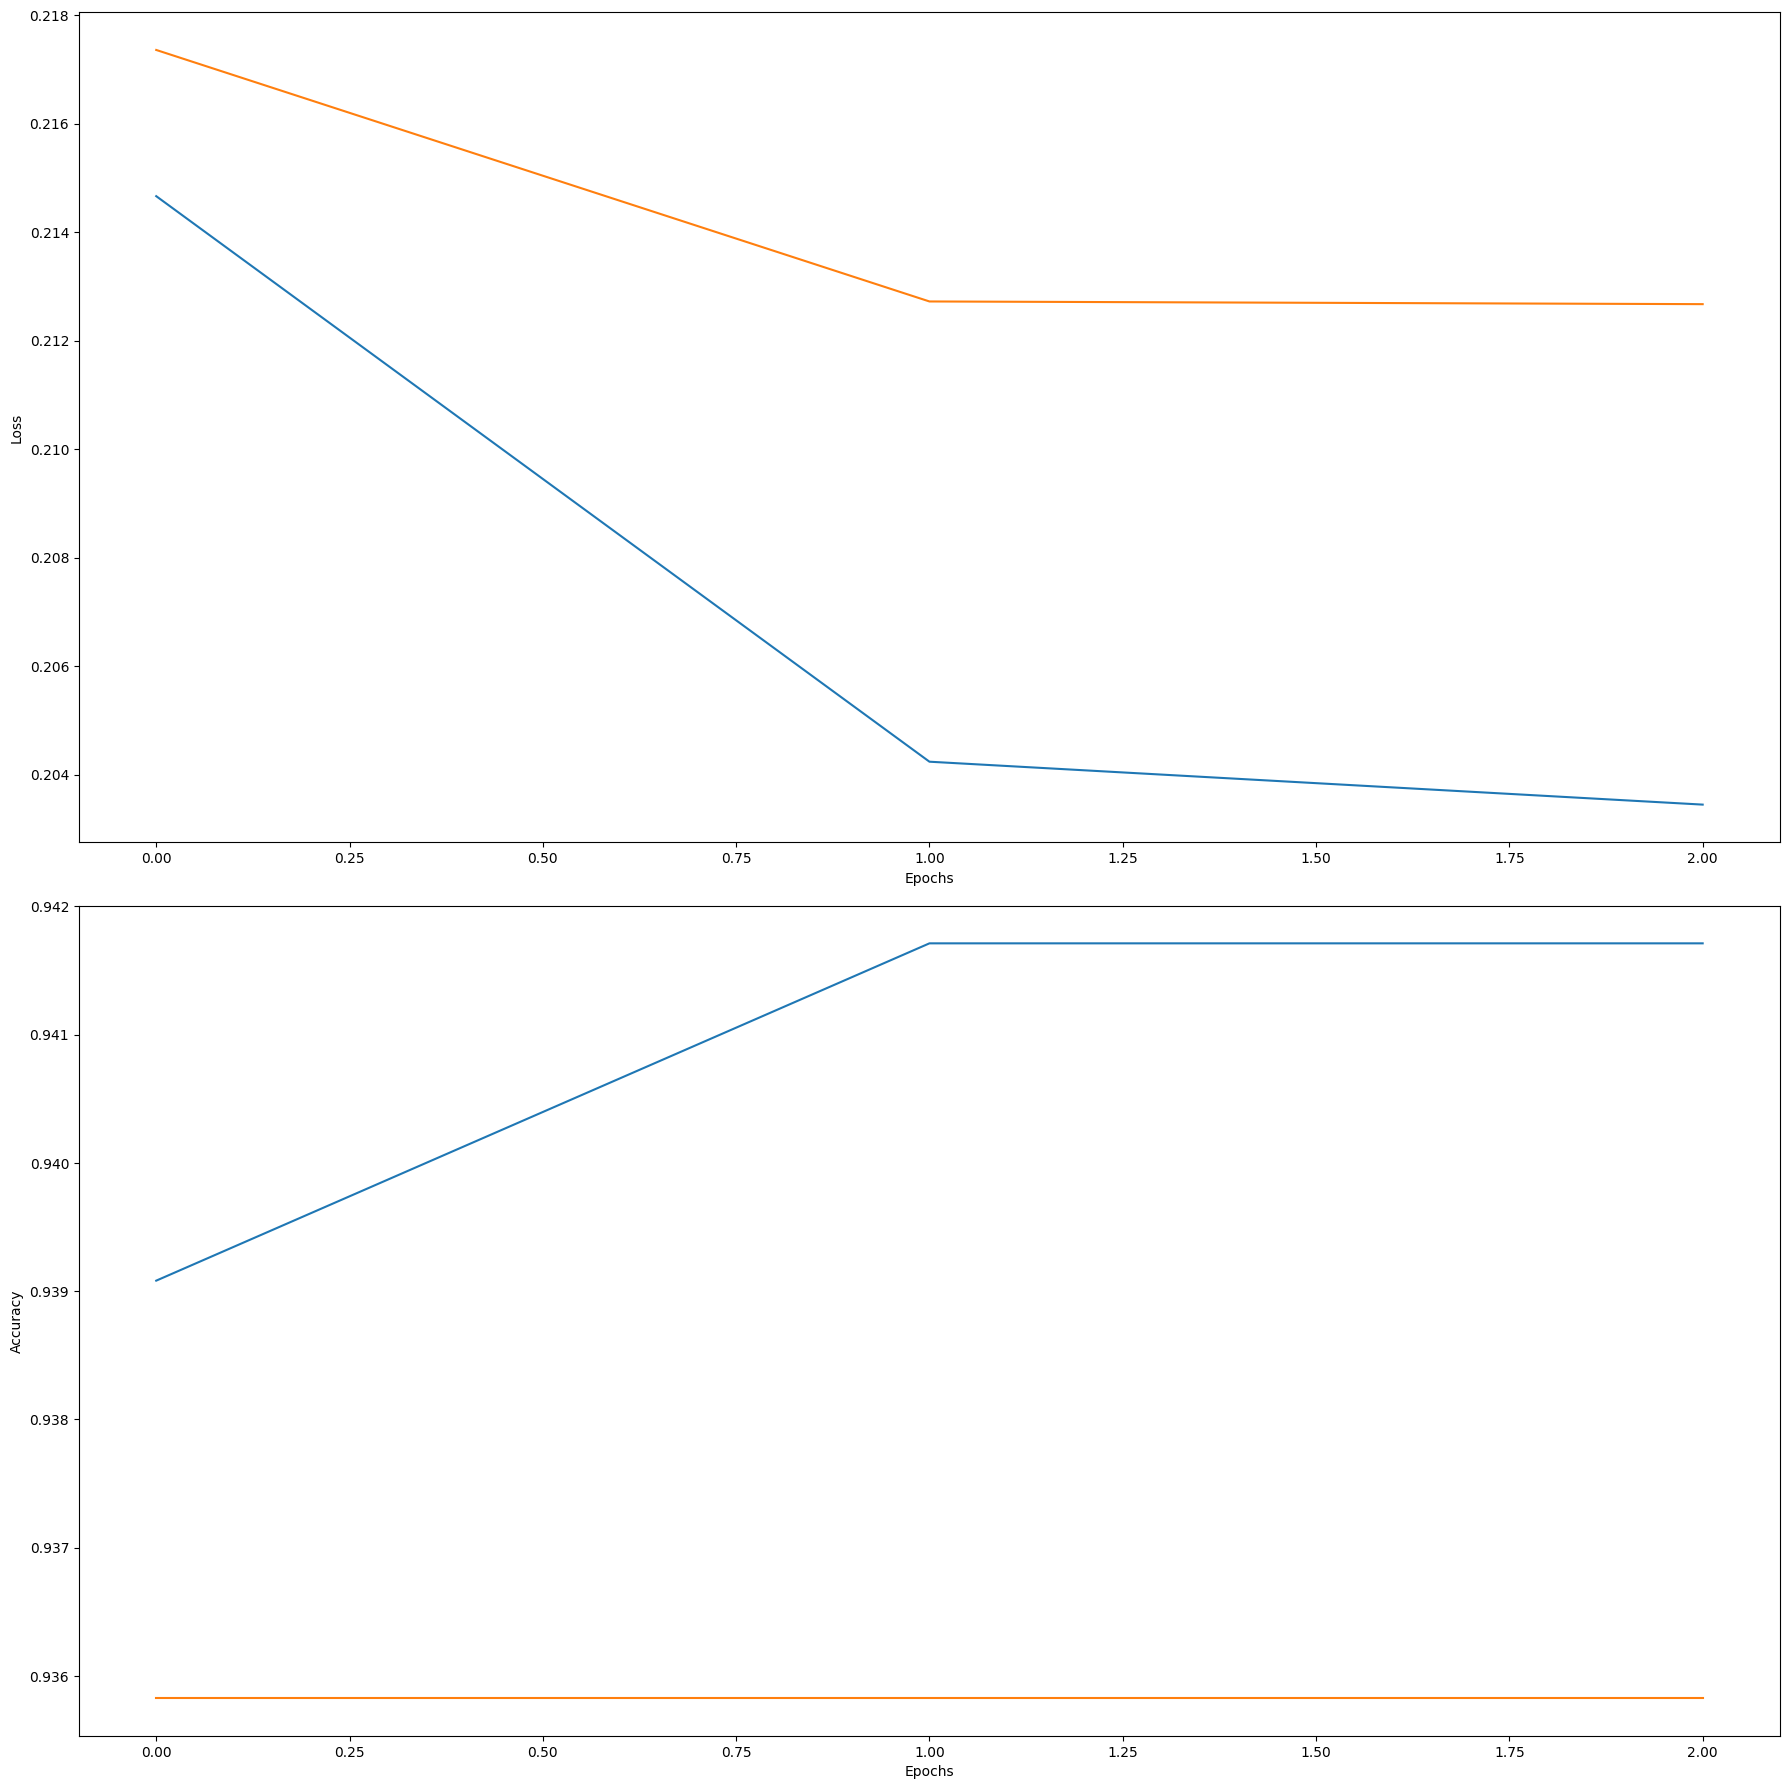

In [34]:
fig, ax = plt.subplots(2, 1, figsize=(18, 18))

ax[0].plot(history['loss'], label='train_loss')
ax[0].plot(history['val_loss'], label='val_loss')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')


ax[1].plot(history['accuracy'], label='accuracy')
ax[1].plot(history['val_accuracy'], label='val_accuracy')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Accuracy')

plt.tight_layout()
plt.show()

#### 4.3. Pretrained Embeddings

#### 4.4. BERT

In [36]:
tokenazer_bert = BertTokenizer.from_pretrained('bert-base-uncased')
bert_model = BertForSequenceClassification.from_pretrained('bert-base-uncased')

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [39]:
X_train_texts = X_train.astype(str).tolist()
X_val_texts   = X_val.astype(str).tolist()

In [40]:
X_train_bert = tokenazer_bert(X_train_texts, padding=True, truncation=True, return_tensors='tf')
X_val_bert = tokenazer_bert(X_val_texts, padding=True, truncation=True, return_tensors='tf')